# Locate + load the parquet (local first; optional S3 download)

In [15]:
from pathlib import Path
import os
import pandas as pd

# ---- configure these ----
TILE = "p089r084"
WORK_DIR = Path("/home/jovyan/scratch/eds-work-optimised") / TILE   # your --work-dir + tile
LOCAL_MANIFEST = WORK_DIR / "manifests" / f"{TILE}_manifest.parquet"

# Optional: S3 URI (if you want to fetch it when local is missing)
S3_URI = "s3://dcceew-epp-data/AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimised/manifests/p089r084_manifest.parquet"

# ---- find local manifest if the expected path isn't present ----
if not LOCAL_MANIFEST.exists():
    candidates = list((WORK_DIR / "manifests").glob("*.parquet"))
    if candidates:
        LOCAL_MANIFEST = candidates[0]
        print(f"[INFO] Using found manifest: {LOCAL_MANIFEST}")
    else:
        print("[WARN] Local manifest not found.")
        print("If you want to download from S3, run the next cell (Cell 1b).")

print(f"[PATH] {LOCAL_MANIFEST}")

# ---- read parquet ----
df = pd.read_parquet(LOCAL_MANIFEST)
print("[OK] Loaded:", df.shape)
df.head()


[PATH] /home/jovyan/scratch/eds-work-optimised/p089r084/manifests/p089r084_manifest.parquet
[OK] Loaded: (51, 10)


,tile,date,platform,product,cloud,target_epsg,lon_min,lat_min,lon_max,lat_max
0,p089r084,20130411,L8,ga_ls8c_ard_3,9.560861,28356,150.096,-35.558,152.617,-33.657
1,p089r084,20130427,L8,ga_ls8c_ard_3,21.926385,28356,150.096,-35.558,152.617,-33.657
2,p089r084,20130630,L8,ga_ls8c_ard_3,1.737040,28356,150.096,-35.558,152.617,-33.657
3,p089r084,20130716,L8,ga_ls8c_ard_3,25.368202,28356,150.096,-35.558,152.617,-33.657
4,p089r084,20130817,L8,ga_ls8c_ard_3,0.028666,28356,150.096,-35.558,152.617,-33.657


# (Optional) Download manifest from S3 into your work dir

In [16]:
from pathlib import Path
import subprocess

TILE = "p089r084"
WORK_DIR = Path("/home/jovyan/scratch/eds-work-optimised") / TILE
WORK_DIR.mkdir(parents=True, exist_ok=True)
(WORK_DIR / "manifests").mkdir(parents=True, exist_ok=True)

S3_URI = "s3://dcceew-epp-data/AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimised/manifests/p089r084_manifest.parquet"
LOCAL_MANIFEST = WORK_DIR / "manifests" / f"{TILE}_manifest.parquet"

cmd = ["aws", "s3", "cp", S3_URI, str(LOCAL_MANIFEST)]
print(" ".join(cmd))
subprocess.check_call(cmd)

import pandas as pd
df = pd.read_parquet(LOCAL_MANIFEST)
print("[OK] Loaded:", df.shape)
df.head()


aws s3 cp s3://dcceew-epp-data/AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimised/manifests/p089r084_manifest.parquet /home/jovyan/scratch/eds-work-optimised/p089r084/manifests/p089r084_manifest.parquet
download: s3://dcceew-epp-data/AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimised/manifests/p089r084_manifest.parquet to ../../../scratch/eds-work-optimised/p089r084/manifests/p089r084_manifest.parquet
[OK] Loaded: (51, 10)


,tile,date,platform,product,cloud,target_epsg,lon_min,lat_min,lon_max,lat_max
0,p089r084,20130411,L8,ga_ls8c_ard_3,9.560861,28356,150.096,-35.558,152.617,-33.657
1,p089r084,20130427,L8,ga_ls8c_ard_3,21.926385,28356,150.096,-35.558,152.617,-33.657
2,p089r084,20130630,L8,ga_ls8c_ard_3,1.737040,28356,150.096,-35.558,152.617,-33.657
3,p089r084,20130716,L8,ga_ls8c_ard_3,25.368202,28356,150.096,-35.558,152.617,-33.657
4,p089r084,20130817,L8,ga_ls8c_ard_3,0.028666,28356,150.096,-35.558,152.617,-33.657


## Inspect columns, dtypes, missing values, date range

In [17]:
import numpy as np
import pandas as pd

print("Columns:", list(df.columns))
display(df.head(3))

print("\nDtypes:")
display(df.dtypes)

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))

# Normalise date to datetime (supports YYYYMMDD)
df2 = df.copy()
df2["date_dt"] = pd.to_datetime(df2["date"].astype(str), format="%Y%m%d", errors="coerce")

print("\nDate range:")
print("min =", df2["date_dt"].min(), "max =", df2["date_dt"].max(), "n_bad =", df2["date_dt"].isna().sum())

print("\nUniques:")
for c in ["tile","platform","product","target_epsg"]:
    if c in df2.columns:
        print(f"{c}: {df2[c].nunique()} -> {sorted(df2[c].dropna().unique())[:10]}")


Columns: ['tile', 'date', 'platform', 'product', 'cloud', 'target_epsg', 'lon_min', 'lat_min', 'lon_max', 'lat_max']


,tile,date,platform,product,cloud,target_epsg,lon_min,lat_min,lon_max,lat_max
0,p089r084,20130411,L8,ga_ls8c_ard_3,9.560861,28356,150.096,-35.558,152.617,-33.657
1,p089r084,20130427,L8,ga_ls8c_ard_3,21.926385,28356,150.096,-35.558,152.617,-33.657
2,p089r084,20130630,L8,ga_ls8c_ard_3,1.737040,28356,150.096,-35.558,152.617,-33.657



Dtypes:


tile            object
date            object
platform        object
product         object
cloud          float64
target_epsg      int64
lon_min        float64
lat_min        float64
lon_max        float64
lat_max        float64
dtype: object


Missing values per column:


tile           0
date           0
platform       0
product        0
cloud          0
target_epsg    0
lon_min        0
lat_min        0
lon_max        0
lat_max        0
dtype: int64


Date range:
min = 2013-04-11 00:00:00 max = 2017-12-02 00:00:00 n_bad = 0

Uniques:
tile: 1 -> ['p089r084']
platform: 1 -> ['L8']
product: 1 -> ['ga_ls8c_ard_3']
target_epsg: 1 -> [np.int64(28356)]


# Quick sanity summaries (counts by year/platform/product)

In [18]:
import pandas as pd

df2 = df.copy()
df2["date_dt"] = pd.to_datetime(df2["date"].astype(str), format="%Y%m%d", errors="coerce")
df2["year"] = df2["date_dt"].dt.year

summary = (
    df2.groupby(["year","platform","product"], dropna=False)
       .size()
       .reset_index(name="n_scenes")
       .sort_values(["year","platform","product"])
)
display(summary.head(20))
display(summary.tail(20))

# Overall counts
display(df2.groupby(["platform","product"]).size().reset_index(name="n").sort_values("n", ascending=False))


,year,platform,product,n_scenes
0,2013,L8,ga_ls8c_ard_3,10
1,2014,L8,ga_ls8c_ard_3,8
2,2015,L8,ga_ls8c_ard_3,8
3,2016,L8,ga_ls8c_ard_3,13
4,2017,L8,ga_ls8c_ard_3,12


,year,platform,product,n_scenes
0,2013,L8,ga_ls8c_ard_3,10
1,2014,L8,ga_ls8c_ard_3,8
2,2015,L8,ga_ls8c_ard_3,8
3,2016,L8,ga_ls8c_ard_3,13
4,2017,L8,ga_ls8c_ard_3,12


,platform,product,n
0,L8,ga_ls8c_ard_3,51


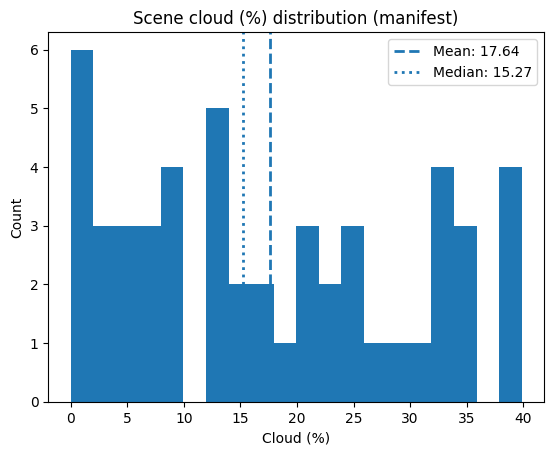

In [19]:
import matplotlib.pyplot as plt
import numpy as np

if "cloud" not in df.columns:
    raise ValueError("No 'cloud' column found in manifest.")

cloud = pd.to_numeric(df["cloud"], errors="coerce").dropna().values
mean_val = float(np.mean(cloud)) if len(cloud) else np.nan
median_val = float(np.median(cloud)) if len(cloud) else np.nan

plt.figure()
plt.hist(cloud, bins=20)
plt.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle=":", linewidth=2, label=f"Median: {median_val:.2f}")
plt.title("Scene cloud (%) distribution (manifest)")
plt.xlabel("Cloud (%)")
plt.ylabel("Count")
plt.legend()
plt.show()


<Figure size 640x480 with 0 Axes>

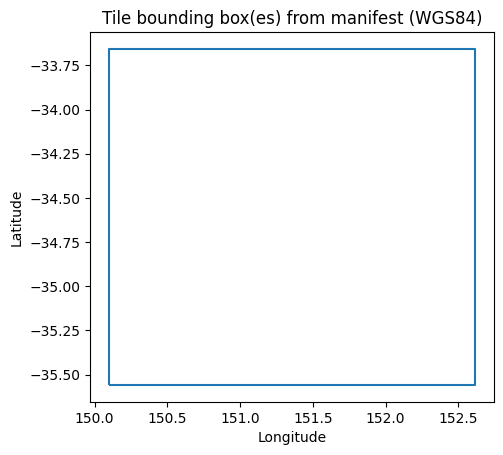

,lon_min,lat_min,lon_max,lat_max,geometry
0,150.096,-35.558,152.617,-33.657,"POLYGON ((152.617 -35.558, 152.617 -33.657, 15..."


In [20]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

needed = {"lon_min","lat_min","lon_max","lat_max"}
if not needed.issubset(df.columns):
    raise ValueError(f"Need columns {sorted(needed)} to plot bboxes. Have: {list(df.columns)}")

# One bbox per row (may be identical); drop duplicates to plot cleanly
bb = df[["lon_min","lat_min","lon_max","lat_max"]].drop_duplicates().copy()

geoms = [box(r.lon_min, r.lat_min, r.lon_max, r.lat_max) for r in bb.itertuples(index=False)]
gdf = gpd.GeoDataFrame(bb, geometry=geoms, crs="EPSG:4326")

plt.figure()
gdf.boundary.plot()
plt.title("Tile bounding box(es) from manifest (WGS84)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

display(gdf.head())


In [21]:
import pyarrow.parquet as pq
from pathlib import Path

pf = pq.ParquetFile(str(LOCAL_MANIFEST))

print("---- Parquet schema ----")
print(pf.schema)

md = pf.metadata
print("\n---- File metadata ----")
print("num_rows:", md.num_rows)
print("num_row_groups:", md.num_row_groups)
print("created_by:", md.created_by)
print("serialized_size:", md.serialized_size)

print("\n---- Row group overview ----")
for i in range(md.num_row_groups):
    rg = md.row_group(i)
    print(f"RowGroup {i}: rows={rg.num_rows}, total_byte_size={rg.total_byte_size}")

# Optional: column stats (may be None depending on writer)
print("\n---- Column statistics (first row group) ----")
rg0 = md.row_group(0)
for j in range(rg0.num_columns):
    col = rg0.column(j)
    stats = col.statistics
    name = col.path_in_schema
    if stats is None:
        print(f"{name}: (no stats)")
    else:
        print(f"{name}: nulls={stats.null_count}, min={stats.min}, max={stats.max}")


---- Parquet schema ----
required group field_id=-1 schema {
  optional binary field_id=-1 tile (String);
  optional binary field_id=-1 date (String);
  optional binary field_id=-1 platform (String);
  optional binary field_id=-1 product (String);
  optional double field_id=-1 cloud;
  optional int64 field_id=-1 target_epsg;
  optional double field_id=-1 lon_min;
  optional double field_id=-1 lat_min;
  optional double field_id=-1 lon_max;
  optional double field_id=-1 lat_max;
}


---- File metadata ----
num_rows: 51
num_row_groups: 1
created_by: parquet-cpp-arrow version 21.0.0
serialized_size: 5080

---- Row group overview ----
RowGroup 0: rows=51, total_byte_size=1939

---- Column statistics (first row group) ----
tile: nulls=0, min=p089r084, max=p089r084
date: nulls=0, min=20130411, max=20171202
platform: nulls=0, min=L8, max=L8
product: nulls=0, min=ga_ls8c_ard_3, max=ga_ls8c_ard_3
cloud: nulls=0, min=0.0062778052626760944, max=39.85163444535886
target_epsg: nulls=0, min=28356, m

In [26]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/jovyan/work-easi-eds/scripts/easi-scripts/optimised_ndvi/scripts")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT not found: {PROJECT_ROOT}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("✅ Added to sys.path:", PROJECT_ROOT)

from lib.s3_io import s3_key_exists
print("✅ lib import OK")



✅ Added to sys.path: /home/jovyan/work-easi-eds/scripts/easi-scripts/optimised_ndvi/scripts
✅ lib import OK


In [27]:
import pandas as pd

# --- set these ---
TILE = "p089r084"
MANIFEST_PATH = "/home/jovyan/scratch/eds-work-optimised/p089r084/manifests/p089r084_manifest.parquet"

BUCKET = "dcceew-epp-data"
PREFIX = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimised"

df = pd.read_parquet(MANIFEST_PATH)

print("rows:", len(df))
print("cols:", list(df.columns))

required = ["tile","date","platform","product","cloud","target_epsg","lon_min","lat_min","lon_max","lat_max"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Manifest missing columns: {missing}")

display(df.head(3))


rows: 51
cols: ['tile', 'date', 'platform', 'product', 'cloud', 'target_epsg', 'lon_min', 'lat_min', 'lon_max', 'lat_max']


,tile,date,platform,product,cloud,target_epsg,lon_min,lat_min,lon_max,lat_max
0,p089r084,20130411,L8,ga_ls8c_ard_3,9.560861,28356,150.096,-35.558,152.617,-33.657
1,p089r084,20130427,L8,ga_ls8c_ard_3,21.926385,28356,150.096,-35.558,152.617,-33.657
2,p089r084,20130630,L8,ga_ls8c_ard_3,1.737040,28356,150.096,-35.558,152.617,-33.657


In [28]:
# Ensure date is a clean YYYYMMDD string
df = df.copy()
df["date"] = df["date"].astype(str).str.replace("-", "", regex=False)
df["platform"] = df["platform"].astype(str)
df["target_epsg"] = df["target_epsg"].astype(int)

df["year"] = df["date"].str.slice(0, 4)

out_dir = (
    PREFIX
    + "/tiles/" + TILE
    + "/ndvi/"
    + df["platform"]
    + "/"
    + df["year"]
    + "/"
    + df["date"]
)

df["ndvi_key"] = out_dir + "/lztmre_" + TILE + "_" + df["date"] + "_ndvi_" + df["target_epsg"].astype(str) + ".tif"
df["ffmask_key"] = out_dir + "/lztmre_" + TILE + "_" + df["date"] + "_ffmask_" + df["target_epsg"].astype(str) + ".tif"

display(df[["date","platform","product","target_epsg","ndvi_key","ffmask_key"]].head(5))


,date,platform,product,target_epsg,ndvi_key,ffmask_key
0,20130411,L8,ga_ls8c_ard_3,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...
1,20130427,L8,ga_ls8c_ard_3,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...
2,20130630,L8,ga_ls8c_ard_3,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...
3,20130716,L8,ga_ls8c_ard_3,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...
4,20130817,L8,ga_ls8c_ard_3,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...


In [29]:
from tqdm.auto import tqdm

rows = []
for r in tqdm(df.itertuples(index=False), total=len(df)):
    ndvi_ok = s3_key_exists(BUCKET, r.ndvi_key)
    fmk_ok  = s3_key_exists(BUCKET, r.ffmask_key)
    rows.append({
        "date": r.date,
        "platform": r.platform,
        "product": r.product,
        "cloud": r.cloud,
        "target_epsg": r.target_epsg,
        "ndvi_key": r.ndvi_key,
        "ffmask_key": r.ffmask_key,
        "ndvi_exists": ndvi_ok,
        "ffmask_exists": fmk_ok,
        "both_exist": bool(ndvi_ok and fmk_ok),
    })

exist_df = pd.DataFrame(rows)

print("Existence counts (ndvi_exists, ffmask_exists):")
display(exist_df.value_counts(["ndvi_exists","ffmask_exists"]).reset_index(name="n"))

print("How many scenes have both outputs?")
display(exist_df["both_exist"].value_counts().rename_axis("both_exist").reset_index(name="n"))

display(exist_df.sort_values(["both_exist","date"]).head(30))


  0%|          | 0/51 [00:00<?, ?it/s]

Existence counts (ndvi_exists, ffmask_exists):


,ndvi_exists,ffmask_exists,n
0,False,False,51


How many scenes have both outputs?


,both_exist,n
0,False,51


,date,platform,product,cloud,target_epsg,ndvi_key,ffmask_key,ndvi_exists,ffmask_exists,both_exist
0,20130411,L8,ga_ls8c_ard_3,9.560861,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
1,20130427,L8,ga_ls8c_ard_3,21.926385,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
2,20130630,L8,ga_ls8c_ard_3,1.737040,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
3,20130716,L8,ga_ls8c_ard_3,25.368202,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
4,20130817,L8,ga_ls8c_ard_3,0.028666,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
5,20130902,L8,ga_ls8c_ard_3,2.531620,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
6,20130918,L8,ga_ls8c_ard_3,0.006278,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
7,20131020,L8,ga_ls8c_ard_3,33.140791,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
8,20131105,L8,ga_ls8c_ard_3,13.782311,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False
9,20131207,L8,ga_ls8c_ard_3,4.838620,28356,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimi...,False,False,False


In [30]:
missing_df = exist_df[~exist_df["both_exist"]].copy()
print("Scenes missing at least one output:", len(missing_df))

display(missing_df[["date","platform","product","cloud","ndvi_exists","ffmask_exists"]].head(50))


Scenes missing at least one output: 51


,date,platform,product,cloud,ndvi_exists,ffmask_exists
0,20130411,L8,ga_ls8c_ard_3,9.560861,False,False
1,20130427,L8,ga_ls8c_ard_3,21.926385,False,False
2,20130630,L8,ga_ls8c_ard_3,1.737040,False,False
3,20130716,L8,ga_ls8c_ard_3,25.368202,False,False
4,20130817,L8,ga_ls8c_ard_3,0.028666,False,False
5,20130902,L8,ga_ls8c_ard_3,2.531620,False,False
6,20130918,L8,ga_ls8c_ard_3,0.006278,False,False
7,20131020,L8,ga_ls8c_ard_3,33.140791,False,False
8,20131105,L8,ga_ls8c_ard_3,13.782311,False,False
9,20131207,L8,ga_ls8c_ard_3,4.838620,False,False


In [31]:
from pathlib import Path

WORK_DIR = Path("/home/jovyan/scratch/eds-work-optimised") / TILE
print("Work dir:", WORK_DIR)
print("Exists:", WORK_DIR.exists())

# search for produced COGs (NDVI + ffmask)
local_tifs = sorted(WORK_DIR.rglob(f"lztmre_{TILE}_*_*.tif"))

print("Local tif count:", len(local_tifs))
for p in local_tifs[:30]:
    print(p)


Work dir: /home/jovyan/scratch/eds-work-optimised/p089r084
Exists: True
Local tif count: 0


In [32]:
import re

pat = re.compile(rf"lztmre_{TILE}_(\d{{8}})_(ndvi|ffmask)_(\d+)\.tif$")
rows = []
for p in local_tifs:
    m = pat.search(p.name)
    if m:
        rows.append({"date": m.group(1), "type": m.group(2), "epsg": int(m.group(3)), "path": str(p)})

local_df = pd.DataFrame(rows)
print("Local parsed rows:", len(local_df))

if len(local_df):
    display(
        local_df
        .pivot_table(index="date", columns="type", values="path", aggfunc="first")
        .reset_index()
        .sort_values("date")
        .head(50)
    )


Local parsed rows: 0


## Check Cloud MAsk calculation

In [35]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/jovyan/work-easi-eds/scripts/easi-scripts/optimised_ndvi/scripts")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("sys.path[0] =", sys.path[0])

# quick sanity check
from lib.s3_io import s3_key_exists
print("lib import OK")


sys.path[0] = /opt/uv/python-installs/cpython-3.12.11-linux-x86_64-gnu/lib/python312.zip
lib import OK


In [37]:
import pandas as pd

TILE = "p089r084"
MANIFEST_PATH = S3_URI

df = pd.read_parquet(MANIFEST_PATH).copy()
print("rows:", len(df))
display(df.head(3))

# pick first row (or filter by date)
row = df.iloc[0].to_dict()
row


rows: 51


,tile,date,platform,product,cloud,target_epsg,lon_min,lat_min,lon_max,lat_max
0,p089r084,20130411,L8,ga_ls8c_ard_3,9.560861,28356,150.096,-35.558,152.617,-33.657
1,p089r084,20130427,L8,ga_ls8c_ard_3,21.926385,28356,150.096,-35.558,152.617,-33.657
2,p089r084,20130630,L8,ga_ls8c_ard_3,1.737040,28356,150.096,-35.558,152.617,-33.657


{'tile': 'p089r084',
 'date': '20130411',
 'platform': 'L8',
 'product': 'ga_ls8c_ard_3',
 'cloud': 9.560861022441605,
 'target_epsg': 28356,
 'lon_min': 150.09600000000012,
 'lat_min': -35.557999999999936,
 'lon_max': 152.61700000000008,
 'lat_max': -33.65699999999998}

In [38]:
import datacube
import numpy as np
import pandas as pd

dc = datacube.Datacube(app="oa_fmask_inspect_lonlat")

date = str(row["date"])
product = str(row["product"])

lon_min = float(row["lon_min"]); lon_max = float(row["lon_max"])
lat_min = float(row["lat_min"]); lat_max = float(row["lat_max"])

t0 = f"{date[:4]}-{date[4:6]}-{date[6:]}"  # YYYY-MM-DD

print("Query:", {"product": product, "time": (t0, t0), "lon": (lon_min, lon_max), "lat": (lat_min, lat_max)})

ds = dc.load(
    product=product,
    measurements=["oa_fmask"],
    time=(t0, t0),
    lon=(lon_min, lon_max),
    lat=(lat_min, lat_max),
    output_crs=f"EPSG:{int(row['target_epsg'])}",
    resolution=(-30, 30),
)

print(ds)
oa = ds.isel(time=0)["oa_fmask"].astype("uint8").values

vals, counts = np.unique(oa, return_counts=True)
tbl = pd.DataFrame({"value": vals, "count": counts})
tbl["pct"] = tbl["count"] / tbl["count"].sum() * 100.0
display(tbl.sort_values("count", ascending=False))


Query: {'product': 'ga_ls8c_ard_3', 'time': ('2013-04-11', '2013-04-11'), 'lon': (150.09600000000012, 152.61700000000008), 'lat': (-35.557999999999936, -33.65699999999998)}
<xarray.Dataset> Size: 168MB
Dimensions:      (time: 3, y: 7155, x: 7820)
Coordinates:
  * time         (time) datetime64[ns] 24B 2013-04-11T23:45:47.384647 ... 201...
  * y            (y) float64 57kB 6.276e+06 6.276e+06 ... 6.061e+06 6.061e+06
  * x            (x) float64 63kB 2.307e+05 2.307e+05 ... 4.653e+05 4.653e+05
    spatial_ref  int32 4B 28356
Data variables:
    oa_fmask     (time, y, x) uint8 168MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:28356
    grid_mapping:  spatial_ref


,value,count,pct
0,0,48159582,86.072877
5,5,5412851,9.674080
1,1,1415464,2.529778
2,2,725718,1.297034
3,3,238468,0.426200
4,4,17,0.000030


In [39]:
def clear_pct_for(values):
    clear = np.isin(oa, list(values))
    return float(clear.mean() * 100.0)

candidates = [
    {0}, {1}, {2}, {3}, {4}, {5},
    {0, 1},
]

out = []
for v in candidates:
    out.append({"clear_values": str(sorted(v)), "clear_pct": clear_pct_for(v), "cloud_pct": 100.0 - clear_pct_for(v)})

display(pd.DataFrame(out).sort_values("clear_pct", ascending=False))


,clear_values,clear_pct,cloud_pct
6,"[0, 1]",88.602655,11.397345
0,[0],86.072877,13.927123
5,[5],9.674080,90.325920
1,[1],2.529778,97.470222
2,[2],1.297034,98.702966
3,[3],0.426200,99.573800
4,[4],0.000030,99.999970


In [40]:
from tqdm.auto import tqdm
from lib.s3_io import s3_key_exists

BUCKET = "dcceew-epp-data"
PREFIX  = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/optimised"
TILE    = "p089r084"

def build_keys(r):
    yyyymmdd = str(r["date"])
    platform = str(r["platform"])
    epsg = int(r["target_epsg"])
    out_dir = f"{PREFIX}/tiles/{TILE}/ndvi/{platform}/{yyyymmdd[:4]}/{yyyymmdd}"
    ndvi_key = f"{out_dir}/lztmre_{TILE}_{yyyymmdd}_ndvi_{epsg}.tif"
    fmk_key  = f"{out_dir}/lztmre_{TILE}_{yyyymmdd}_ffmask_{epsg}.tif"
    return ndvi_key, fmk_key

chk = df.copy()
chk[["ndvi_key", "ffmask_key"]] = chk.apply(lambda r: pd.Series(build_keys(r)), axis=1)

rows = []
for _, r in tqdm(chk.iterrows(), total=len(chk)):
    rows.append({
        "date": r["date"],
        "ndvi_exists": s3_key_exists(BUCKET, r["ndvi_key"]),
        "ffmask_exists": s3_key_exists(BUCKET, r["ffmask_key"]),
    })

exist_df = pd.DataFrame(rows)
display(exist_df.value_counts(["ndvi_exists", "ffmask_exists"]).reset_index(name="n"))
display(exist_df.head(10))


  0%|          | 0/51 [00:00<?, ?it/s]

,ndvi_exists,ffmask_exists,n
0,False,False,51


,date,ndvi_exists,ffmask_exists
0,20130411,False,False
1,20130427,False,False
2,20130630,False,False
3,20130716,False,False
4,20130817,False,False
5,20130902,False,False
6,20130918,False,False
7,20131020,False,False
8,20131105,False,False
9,20131207,False,False


In [34]:
import datacube
import numpy as np
import pandas as pd
from datacube.utils.geometry import Geometry, CRS
from shapely.geometry import box, mapping

# pick a date you just tested
date = "20130411"
product = "ga_ls8c_ard_3"
target_epsg = 28356

lon_min, lat_min, lon_max, lat_max = 150.096, -35.558, 152.617, -33.657

dc = datacube.Datacube(app="oa_fmask_inspect")

tile_poly = box(lon_min, lat_min, lon_max, lat_max)
geopolygon = Geometry(mapping(tile_poly), crs=CRS("EPSG:4326"))

t0 = f"{date[:4]}-{date[4:6]}-{date[6:]}"
ds = dc.load(
    product=product,
    measurements=["oa_fmask"],
    geopolygon=geopolygon,
    time=(t0, t0),
    output_crs=f"EPSG:{target_epsg}",
    resolution=(-30, 30),
)

oa = ds.isel(time=0)["oa_fmask"].astype("uint8").values

vals, counts = np.unique(oa, return_counts=True)
tbl = pd.DataFrame({"value": vals, "count": counts})
tbl["pct"] = tbl["count"] / tbl["count"].sum() * 100.0

display(tbl.sort_values("count", ascending=False))


/tmp/ipykernel_4026/3709702025.py:4: DeprecationWarning: datacube.utils.geometry is now deprecated. Please use the odc-geo library instead.
  from datacube.utils.geometry import Geometry, CRS


AssertionError: 

In [ ]:
import numpy as np

CLEAR_VALUE = 0  # change this after you see the table from Cell 1

valid = np.ones_like(oa, dtype=bool)  # if you later find nodata, we can exclude it here
clear = (oa == CLEAR_VALUE) & valid

clear_pct = clear.mean() * 100.0
cloud_pct = 100.0 - clear_pct

print(f"Using CLEAR_VALUE={CLEAR_VALUE}")
print(f"Clear% = {clear_pct:.2f}")
print(f"Cloud% (derived) = {cloud_pct:.2f}")
